In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import scipy.stats as stats
import seaborn as sns
import glob
from matplotlib.colors import LinearSegmentedColormap
from mpl_toolkits.axes_grid1 import make_axes_locatable


In [2]:
# Parameters to make figures work better with illustrator 
import matplotlib 
# For higher resoltion figures
plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300

matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
plt.rcParams["font.family"] = "Helvetica"
plt.rcParams['pdf.fonttype'] = 42

In [3]:
# Read in the paddle predictions for all the mutated tiles
# paddle = pd.read_csv('../../Data/Top5_PADDLE_tiled_replaced_full_df.csv', index_col=0)
paddle = pd.read_csv('../../Data/pooja_seqs/Top15_PADDLE_tiled_replaced_full_df.csv', index_col=0)
paddle

,Unnamed: 0,id,sequence,preds,tile,position
0,0,seq0|g..X>X(p.Asp52Asp)_wt_tile0,DTEESSVSPPNPTLPVQGSPLIVVEDPSDTVAMKRARNTLAARKSR...,-0.105847,0,52
1,1,seq0|g..X>X(p.Asp52Ala)_tile0,ATEESSVSPPNPTLPVQGSPLIVVEDPSDTVAMKRARNTLAARKSR...,-0.114436,0,52
2,2,seq0|g..X>X(p.Asp52Arg)_tile0,RTEESSVSPPNPTLPVQGSPLIVVEDPSDTVAMKRARNTLAARKSR...,-0.116015,0,52
3,3,seq0|g..X>X(p.Asp52Asn)_tile0,NTEESSVSPPNPTLPVQGSPLIVVEDPSDTVAMKRARNTLAARKSR...,-0.109646,0,52
4,4,seq0|g..X>X(p.Asp52Asp)_tile0,DTEESSVSPPNPTLPVQGSPLIVVEDPSDTVAMKRARNTLAARKSR...,-0.105847,0,52
...,...,...,...,...,...,...
92374,92374,seq14|g..X>X(p.Pro134Ser)_tile52,PLIIDEELEVGDALRANRRRSGTDSSPGNHSSITGVKSRKRDQPLP...,0.127096,52,134
92375,92375,seq14|g..X>X(p.Pro134Thr)_tile52,PLIIDEELEVGDALRANRRRSGTDSSPGNHSSITGVKSRKRDQPLP...,0.127804,52,134
92376,92376,seq14|g..X>X(p.Pro134Trp)_tile52,PLIIDEELEVGDALRANRRRSGTDSSPGNHSSITGVKSRKRDQPLP...,0.512797,52,134
92377,92377,seq14|g..X>X(p.Pro134Tyr)_tile52,PLIIDEELEVGDALRANRRRSGTDSSPGNHSSITGVKSRKRDQPLP...,0.256165,52,134


In [4]:
# Read in the ADHunter predictions for all the mutated tiles
adhunter = pd.read_csv('../../Data/pooja_seqs/Top15_ADHunter_differences_tiled_replaced_full_df.csv', index_col=0)
adhunter

,id,sequence,pred_mutated,tile,position,pred_reference,pred_difference,fold_difference,orig_AA,new_AA
0,seq0|g..X>X(p.Gly40Ala)_tile0,AAWYSLFPDAAPDTEESSVSPPNPTLPVQGSPLIVVEDPS,60073.726562,0,40,63531.929688,-3458.203125,0.945567,G,A
1,seq0|g..X>X(p.Gly40Ala)_tile0,AAWYSLFPDAAPDTEESSVSPPNPTLPVQGSPLIVVEDPS,60073.726562,0,40,19651.066406,40422.660156,3.057021,G,A
2,seq0|g..X>X(p.Gly40Ala)_tile0,AAWYSLFPDAAPDTEESSVSPPNPTLPVQGSPLIVVEDPS,60073.726562,0,40,22449.921875,37623.804688,2.675899,G,A
3,seq0|g..X>X(p.Gly40Ala)_tile0,AAWYSLFPDAAPDTEESSVSPPNPTLPVQGSPLIVVEDPS,60073.726562,0,40,21928.886719,38144.839844,2.739479,G,A
4,seq0|g..X>X(p.Gly40Ala)_tile0,AAWYSLFPDAAPDTEESSVSPPNPTLPVQGSPLIVVEDPS,60073.726562,0,40,17182.433594,42891.292969,3.496229,G,A
...,...,...,...,...,...,...,...,...,...,...
14096795,seq14|g..X>X(p.Leu147Ser)_tile39,PGNHSSITGVKSRKRDQPLPPIIVDDPNDPVALKRARNTS,59635.656250,39,147,52922.812500,6712.843750,1.126842,L,S
14096796,seq14|g..X>X(p.Leu147Thr)_tile39,PGNHSSITGVKSRKRDQPLPPIIVDDPNDPVALKRARNTT,62766.007812,39,147,52922.812500,9843.195312,1.185992,L,T
14096797,seq14|g..X>X(p.Leu147Trp)_tile39,PGNHSSITGVKSRKRDQPLPPIIVDDPNDPVALKRARNTW,57005.214844,39,147,52922.812500,4082.402344,1.077139,L,W
14096798,seq14|g..X>X(p.Leu147Tyr)_tile39,PGNHSSITGVKSRKRDQPLPPIIVDDPNDPVALKRARNTY,57457.328125,39,147,52922.812500,4534.515625,1.085682,L,Y


In [15]:
# Extract useful information about the mutation from the id column 

# Tile: where in the 53aa tile the mutation is centered
paddle['tile'] = paddle['id'].str.split("_").str[-1].str[4:].astype('int')

# Position: where in the full length sequence the tile is centered
paddle["position"] = paddle["id"].str.split('(').str[1].str.extract("\w{3}(\d+)\w{3}")[0].astype("int")

# Seq_id : Which full length TF this sequence came from
paddle["seq_id"] = paddle['id'].str.split("|").str[0]

# Create two dataframes for the WT and mutant sequences
only_wt_paddle = paddle[paddle['id'].str.contains('wt')]
no_wt_paddle = paddle[~paddle['id'].str.contains('wt')]


In [5]:
# Extract useful information about the mutation from the id column 

# Tile: where in the 53aa tile the mutation is centered
adhunter['tile'] = adhunter['id'].str.split("_").str[-1].str[4:].astype('int')

# Position: where in the full length sequence the tile is centered
adhunter["position"] = adhunter["id"].str.split('(').str[1].str.extract("\w{3}(\d+)\w{3}")[0].astype("int")

# Seq_id : Which full length TF this sequence came from
adhunter["seq_id"] = adhunter['id'].str.split("|").str[0]

# Create two dataframes for the WT and mutant sequences
only_wt_adhunter = adhunter[adhunter['id'].str.contains('wt')]
no_wt_adhunter = adhunter[~adhunter['id'].str.contains('wt')]


In [16]:
# Merge the WT and mutant tiles so that each row contains one mutant tile and the corresponding WT tile
paddle_difference = no_wt_paddle.merge(only_wt_paddle[['tile', 'position', 'preds', 'seq_id']], how = 'left', on = ['tile', 'position', 'seq_id'])
paddle_difference = paddle_difference.rename(columns = {'preds_x':'pred_mutated', 'preds_y':'pred_reference'})

# Calculate how much the predicted activity changed
paddle_difference['pred_difference'] =  - paddle_difference['pred_reference'] + paddle_difference['pred_mutated'] # Flipped this to match my expectation
paddle_difference['fold_difference'] = paddle_difference['pred_mutated'] / paddle_difference['pred_reference']

paddle_difference["orig_AA"] = paddle_difference["id"].str.extract(r'p\.(...)')
paddle_difference["new_AA"] = paddle_difference["id"].str.extract(r'p\.\w{3}\d+(\w{3})')

# Converting to 1 letter code
aa_dict = {
    'Ala': 'A', 'Arg': 'R', 'Asn': 'N', 'Asp': 'D', 'Cys': 'C',
    'Glu': 'E', 'Gln': 'Q', 'Gly': 'G', 'His': 'H', 'Ile': 'I',
    'Leu': 'L', 'Lys': 'K', 'Met': 'M', 'Phe': 'F', 'Pro': 'P',
    'Ser': 'S', 'Thr': 'T', 'Trp': 'W', 'Tyr': 'Y', 'Val': 'V'
}

paddle_difference["orig_AA"] = paddle_difference["orig_AA"].map(aa_dict)
paddle_difference["new_AA"] = paddle_difference["new_AA"].map(aa_dict)
paddle_difference

,Unnamed: 0,id,sequence,pred_mutated,tile,position,seq_id,pred_reference,pred_difference,fold_difference,orig_AA,new_AA
0,1,seq0|g..X>X(p.Asp52Ala)_tile0,ATEESSVSPPNPTLPVQGSPLIVVEDPSDTVAMKRARNTLAARKSR...,-0.114436,0,52,seq0,-0.105847,-0.008589,1.081144,D,A
1,2,seq0|g..X>X(p.Asp52Arg)_tile0,RTEESSVSPPNPTLPVQGSPLIVVEDPSDTVAMKRARNTLAARKSR...,-0.116015,0,52,seq0,-0.105847,-0.010169,1.096069,D,R
2,3,seq0|g..X>X(p.Asp52Asn)_tile0,NTEESSVSPPNPTLPVQGSPLIVVEDPSDTVAMKRARNTLAARKSR...,-0.109646,0,52,seq0,-0.105847,-0.003799,1.035896,D,N
3,4,seq0|g..X>X(p.Asp52Asp)_tile0,DTEESSVSPPNPTLPVQGSPLIVVEDPSDTVAMKRARNTLAARKSR...,-0.105847,0,52,seq0,-0.105847,0.000000,1.000000,D,D
4,5,seq0|g..X>X(p.Asp52Cys)_tile0,CTEESSVSPPNPTLPVQGSPLIVVEDPSDTVAMKRARNTLAARKSR...,-0.103802,0,52,seq0,-0.105847,0.002045,0.980683,D,C
...,...,...,...,...,...,...,...,...,...,...,...,...
977315,92374,seq14|g..X>X(p.Pro134Ser)_tile52,PLIIDEELEVGDALRANRRRSGTDSSPGNHSSITGVKSRKRDQPLP...,0.127096,52,134,seq14,0.130700,-0.003604,0.972426,P,S
977316,92375,seq14|g..X>X(p.Pro134Thr)_tile52,PLIIDEELEVGDALRANRRRSGTDSSPGNHSSITGVKSRKRDQPLP...,0.127804,52,134,seq14,0.130700,-0.002896,0.977840,P,T
977317,92376,seq14|g..X>X(p.Pro134Trp)_tile52,PLIIDEELEVGDALRANRRRSGTDSSPGNHSSITGVKSRKRDQPLP...,0.512797,52,134,seq14,0.130700,0.382097,3.923469,P,W
977318,92377,seq14|g..X>X(p.Pro134Tyr)_tile52,PLIIDEELEVGDALRANRRRSGTDSSPGNHSSITGVKSRKRDQPLP...,0.256165,52,134,seq14,0.130700,0.125466,1.959952,P,Y


In [29]:
# Plot the results

# Define a color map
colors = [(1, 0, 0), (1, 1, 1), (0, 0, 1)]  # Blue, White, Red
n_bins = 100  # Number of color bins
cmap_name = "custom_colormap"
custom_cmap = LinearSegmentedColormap.from_list(cmap_name, colors, N=n_bins)
custom_cmap.set_bad(color='white', alpha=1.0)  # Handle NaN values, if any
colors = {'A': 'purple', 'C': 'darkorange', 'E': 'blue', 'D': 'blue', 'G': 'darkorange', 
                  'F': 'indigo', 'I': 'purple', 'H': 'green', 'K': 'green', 'M': 'purple', 
                  'L': 'purple', 'N': 'darkslategray', 'Q': 'darkslategray', 'P': 'darkorange', 'S': 'darkslategray', 
                  'R': 'green', 'T': 'darkslategray', 'W': 'indigo', 'V': 'purple', 'Y': 'indigo'}

amino_acids = ["R","K","H","D","E","M","I","L","V","A","F","Y","W","Q","N","S","T","G","P","C"]

# Average the differences for all mutations in the same tile position with the same mutant residue
pivot = paddle_difference.pivot_table(values='pred_difference', columns='tile', index='new_AA', aggfunc = np.mean)
pivot = pivot.reindex(amino_acids, axis = 0)

lim = max(abs(pivot.min().min()), pivot.max().max())

fig = plt.figure(figsize=(8, 3))
ax = fig.add_subplot(111)

# Plot the heatmap
im1 = ax.imshow(pivot, cmap=custom_cmap, aspect='auto',vmin=-lim,vmax=lim)
ax.set_yticks(range(len(pivot.index)), pivot.index)  # Label x-axis with column names
ax.set_xticks(np.arange(53, step=4))

# Recolor the y-axis labels
for ytic in ax.get_yticklabels():
    if ytic.get_text() in colors.keys(): 
        ytic.set_color(colors[ytic.get_text()])

ax.tick_params(axis='x', which='major', labelsize=15) 
ax.tick_params(axis='y', which='major', labelsize=8) 
title_font = {'fontsize': 15, 'fontweight': 'bold', 'fontname': 'Arial'}
ax.set_title("PADDLE Interpretation", fontdict=title_font)

divider = make_axes_locatable(ax)
cax = divider.append_axes("bottom", size="3%", pad=0.4)  # 3% of ax height, adjust as needed

# Add colorbar to that axis
cbar = fig.colorbar(im1, cax=cax, orientation="horizontal")
cbar.ax.tick_params(labelsize=10)  # make ticks bigger

plt.savefig('../../figures/for_revision/Paddle_interpretation_15_seqs.pdf', dpi=1000, bbox_inches='tight')

NameError: name 'paddle_difference' is not defined

/var/folders/34/1pw3__x51kdfyh3vk72f5vc80000gn/T/ipykernel_33360/3545376911.py:17: FutureWarning: The provided callable <function mean at 0x1053060e0> is currently using DataFrameGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  pivot = adhunter.pivot_table(values='pred_difference', columns='tile', index='new_AA', aggfunc = np.mean)
1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp


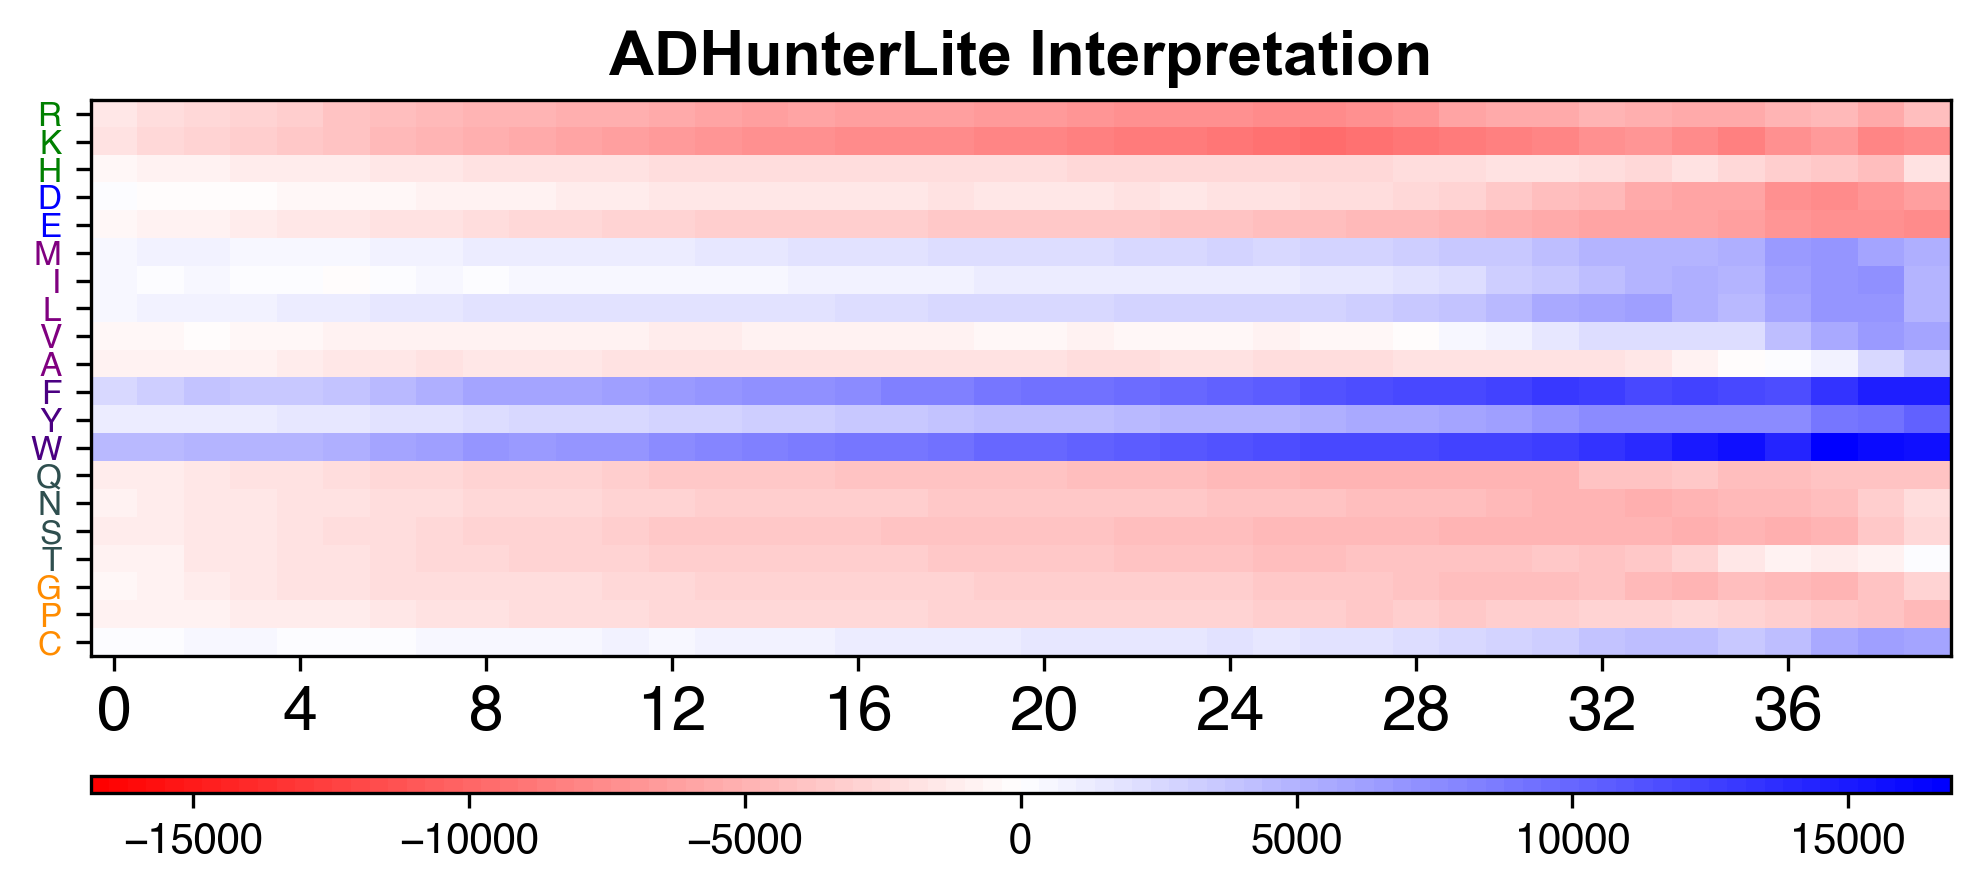

In [6]:
# Plot the ADHunter result

# Define our colormap 
colors = [(1, 0, 0), (1, 1, 1), (0, 0, 1)]  # Blue, White, Red
n_bins = 100  # Number of color bins
cmap_name = "custom_colormap"
custom_cmap = LinearSegmentedColormap.from_list(cmap_name, colors, N=n_bins)
custom_cmap.set_bad(color='white', alpha=1.0)  # Handle NaN values, if any
colors = {'A': 'purple', 'C': 'darkorange', 'E': 'blue', 'D': 'blue', 'G': 'darkorange', 
                  'F': 'indigo', 'I': 'purple', 'H': 'green', 'K': 'green', 'M': 'purple', 
                  'L': 'purple', 'N': 'darkslategray', 'Q': 'darkslategray', 'P': 'darkorange', 'S': 'darkslategray', 
                  'R': 'green', 'T': 'darkslategray', 'W': 'indigo', 'V': 'purple', 'Y': 'indigo'}

amino_acids = ["R","K","H","D","E","M","I","L","V","A","F","Y","W","Q","N","S","T","G","P","C"]

# Average the prediction differences based on position in tile and mutant residue
pivot = adhunter.pivot_table(values='pred_difference', columns='tile', index='new_AA', aggfunc = np.mean)
pivot = pivot.reindex(amino_acids, axis = 0)
lim = max(abs(pivot.min().min()), pivot.max().max())

fig = plt.figure(figsize=(8, 3))
ax = fig.add_subplot(111)

# Plot the colormap
im1 = ax.imshow(pivot, cmap=custom_cmap, aspect='auto',vmin=-lim,vmax=lim)
ax.set_yticks(range(len(pivot.index)), pivot.index)  # Label x-axis with column names
ax.set_xticks(np.arange(40, step=4))

# Color the amino acid labels
for ytic in ax.get_yticklabels():
    if ytic.get_text() in colors.keys(): 
        ytic.set_color(colors[ytic.get_text()])

ax.tick_params(axis='x', which='major', labelsize=15) 
ax.tick_params(axis='y', which='major', labelsize=8) 
title_font = {'fontsize': 15, 'fontweight': 'bold', 'fontname': 'Arial'}
ax.set_title("ADHunterLite Interpretation", fontdict=title_font)


divider = make_axes_locatable(ax)
cax = divider.append_axes("bottom", size="3%", pad=0.4)  # 3% of ax height, adjust as needed

# Add colorbar to that axis
cbar = fig.colorbar(im1, cax=cax, orientation="horizontal")
cbar.ax.tick_params(labelsize=10)  # make ticks bigger


plt.savefig('../../figures/for_revision/ADHunter_Pooja_interpretation.pdf', dpi=1000, bbox_inches='tight')
plt.savefig('../../figures/for_revision/ADHunter_Pooja_interpretation.png', dpi=1000, bbox_inches='tight')